# Analise o alinhamento de contexto - Testes

## Importação e configuração

In [2]:
import pandas as pd
import json
import re
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [3]:
pd.set_option('display.max_colwidth', None)  # Remove truncamento de colunas
pd.set_option('display.max_rows', 50)        # Aumenta limite de linhas exibidas

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

## Carregamento dos dados

In [4]:

DATA_PATH = "../data/testing_analysis/testing_validity_data.json"
if os.path.exists(DATA_PATH):
    with open(DATA_PATH, 'r', encoding='utf-8') as f:
        raw_data = json.load(f)
    
    # Converter para DataFrame
    df = pd.DataFrame(raw_data)
    
#     print(f"Total de repositórios carregados: {len(df)}")
    
#     # 2. Pré-processamento: Consolidar todo o texto de teste em uma única coluna
#     def consolidate_text(sections):
#         return "\n".join([s['content'] for s in sections])
    
#     df['full_test_text'] = df['testing_sections'].apply(consolidate_text)
#     df['file_count'] = df['file_tree'].apply(len)
    
#     print("\nEstrutura do DataFrame:")
#     display(df.info())
    
#     print("\nPrimeiros 5 registros (sem truncamento):")
#     display(df[['repo', 'file_type', 'full_test_text']].head())
# else:
#     print(f"Arquivo {DATA_PATH} não encontrado.")
#     df = pd.DataFrame()

# # Função para inspeção detalhada de um repositório
# def inspect_repo(repo_name):
#     try:
#         row = df[df['repo'] == repo_name].iloc[0]
#         print(f"=== Inspeção: {repo_name} ===")
#         print(f"\n[Instruções de Teste]:\n{row['full_test_text']}")
#         print(f"\n[Árvore de Arquivos (Amostra 20)]: {row['file_tree'][:20]}")
#         print(f"\nTotal de arquivos no repo: {row['file_count']}")
    # except IndexError:
    #     print(f"Repositório {repo_name} não encontrado no DataFrame.")

In [5]:
df.columns

Index(['repo', 'file_type', 'testing_sections', 'file_tree'], dtype='str')

In [8]:
df.iloc[0]

repo                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    

## Exemplo de Inspeção Detalhada

Use a função `inspect_repo('nome/repo')` para ler o conteúdo completo de um repositório específico de forma legível.

In [7]:
if not df.empty:
    inspect_repo(df['repo'].iloc[0])

NameError: name 'inspect_repo' is not defined

## 1. Definição de Marcadores de Frameworks

Mapeamos palavras-chave de frameworks para arquivos de configuração que comprovam sua existência.

In [ ]:
framework_markers = {
    "jest": ["jest.config", "package.json"],
    "pytest": ["pytest.ini", "conftest.py", "tox.ini"],
    "junit": ["pom.xml", "build.gradle", "src/test/java"],
    "maven": ["pom.xml"],
    "gradle": ["build.gradle", "build.gradle.kts"],
    "mocha": [".mocharc", "package.json"],
    "vitest": ["vitest.config"],
    "cypress": ["cypress.config", "cypress/"],
    "playwright": ["playwright.config"],
    "tox": ["tox.ini"],
    "phpunit": ["phpunit.xml"],
    "rspec": [".rspec", "spec/"],
    "cargo": ["Cargo.toml"],
    "npm": ["package.json"],
    "yarn": ["yarn.lock"],
    "pnpm": ["pnpm-lock.yaml"]
}

## 2. Auditoria de Fidelidade via Pandas

Utilizamos operações vetorizadas e `apply` para validar cada repositório contra sua árvore de arquivos.

In [ ]:
def audit_row(row):
    text = row['full_test_text'].lower()
    tree = [f.lower() for f in row['file_tree']]
    
    detected_frameworks = []
    for fw in framework_markers.keys():
        if fw in text:
            detected_frameworks.append(fw)
            
    # Validar frameworks
    fw_matches = 0
    drift_details = []
    
    for fw in detected_frameworks:
        markers = framework_markers[fw]
        exists = any(any(m in f for m in markers) for f in tree)
        if exists: fw_matches += 1
        else: drift_details.append(fw)
            
    # Validar caminhos
    paths_in_text = re.findall(r'[`"\s]([a-zA-Z0-9_\-\./]+/[a-zA-Z0-9_\-\./]*)[`"\s]', text)
    paths_in_text = list(set([p.strip('./').strip('/') for p in paths_in_text if '/' in p]))
    
    path_matches = 0
    for p in paths_in_text:
        if p == "" or len(p) < 3: continue
        if any(f.startswith(p) for f in tree): path_matches += 1
            
    return pd.Series({
        "fw_mentions": len(detected_frameworks),
        "fw_matches": fw_matches,
        "fw_drifts": len(detected_frameworks) - fw_matches,
        "fw_drift_list": ", ".join(drift_details),
        "path_mentions": len(paths_in_text),
        "path_matches": path_matches,
        "path_drifts": len(paths_in_text) - path_matches
    })

if not df.empty:
    # Aplicar auditoria e concatenar resultados
    df_results = df.apply(audit_row, axis=1)
    df_final = pd.concat([df[['repo', 'file_type']], df_results], axis=1)
    
    # Cálculo do Alignment Score
    df_final['alignment_score'] = (df_final['fw_matches'] + df_final['path_matches']) / \
                                  (df_final['fw_mentions'] + df_final['path_mentions']).replace(0, 1)
    
    display(df_final.head())
else:
    df_final = pd.DataFrame()

,repo,file_type,fw_mentions,fw_matches,fw_drifts,fw_drift_list,path_mentions,path_matches,path_drifts,alignment_score
0,Homebrew/homebrew-core,AGENTS.md,0,0,0,,0,0,0,0.000000
1,JuliaLang/julia,AGENTS.md,0,0,0,,1,1,0,1.000000
2,StarRocks/starrocks,AGENTS.md,0,0,0,,15,14,1,0.933333
3,StarRocks/starrocks,CLAUDE.md,0,0,0,,15,14,1,0.933333
4,TriliumNext/trilium,CLAUDE.md,3,3,0,,0,0,0,1.000000


## 3. Visualização do Alinhamento de Contexto

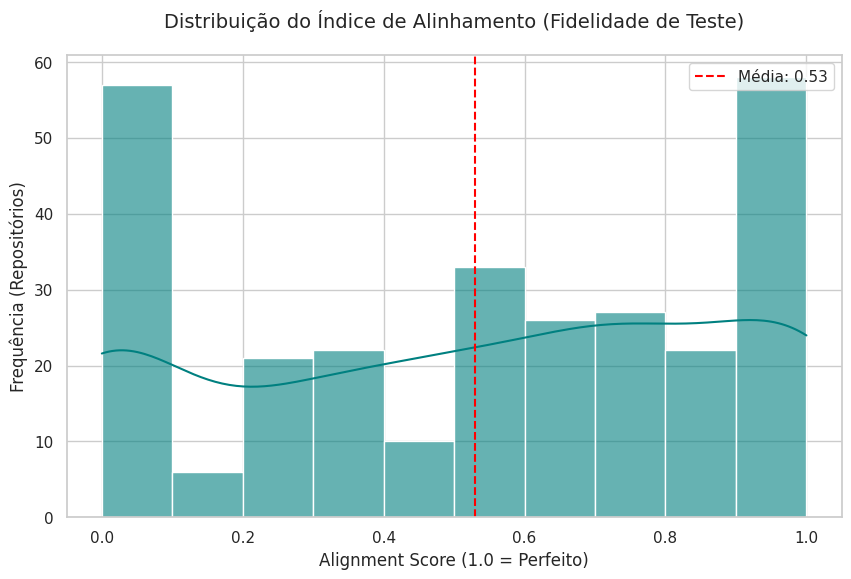

In [ ]:
if not df_final.empty:
    plt.figure(figsize=(10, 6))
    sns.histplot(df_final['alignment_score'], bins=10, kde=True, color='teal', alpha=0.6)
    plt.axvline(df_final['alignment_score'].mean(), color='red', linestyle='--', label=f'Média: {df_final["alignment_score"].mean():.2f}')
    
    plt.title("Distribuição do Índice de Alinhamento (Fidelidade de Teste)", fontsize=14, pad=20)
    plt.xlabel("Alignment Score (1.0 = Perfeito)", fontsize=12)
    plt.ylabel("Frequência (Repositórios)", fontsize=12)
    plt.legend()
    plt.show()
else:
    print("DataFrame de resultados vazio.")

## 4. Análise de Drift por Framework

Identificamos quais ferramentas são citadas com frequência sem terem suporte técnico real.

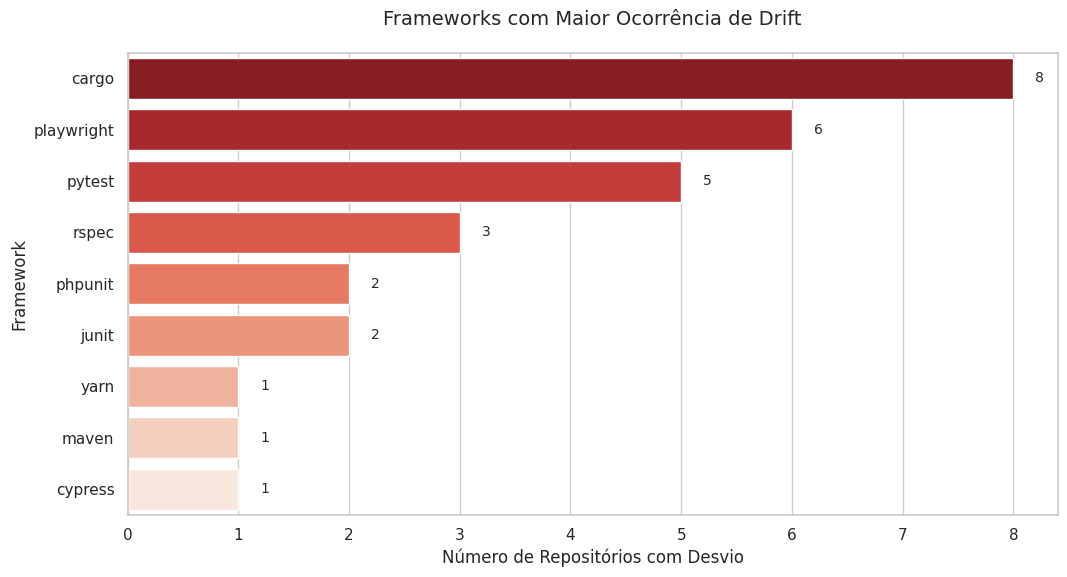

In [ ]:
if not df_final.empty:
    drifted_series = df_final['fw_drift_list'].str.split(', ').explode()
    drifted_series = drifted_series[drifted_series != ""].value_counts()

    if not drifted_series.empty:
        plt.figure(figsize=(12, 6))
        ax = sns.barplot(x=drifted_series.values, y=drifted_series.index, hue=drifted_series.index, palette='Reds_r', legend=False)
        
        for i, v in enumerate(drifted_series.values):
            ax.text(v + 0.2, i, str(v), va='center', fontsize=10)
            
        plt.title("Frameworks com Maior Ocorrência de Drift", fontsize=14, pad=20)
        plt.xlabel("Número de Repositórios com Desvio", fontsize=12)
        plt.ylabel("Framework", fontsize=12)
        plt.show()
    else:
        print("Nenhum drift de framework detectado.")